<a href="https://colab.research.google.com/github/Jager1026/proyecto_IA_financial_news/blob/main/Proyecto_Grupo_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
financial_news = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/financial_news_events.csv", encoding='latin-1')

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
!pip install faker

In [ ]:
!pip install -U scikit-learn

In [ ]:
# synthetic_news_events_10000_with_categorical_sentiment.py
# Requisitos: pip install pandas numpy faker tqdm
import pandas as pd
import numpy as np
import random
from faker import Faker
from datetime import datetime, timedelta
from tqdm import tqdm

fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)

N = 10000

# Columnas objetivo
COLUMNS = [
    "Date",
    "Headline",
    "Source",
    "Market_Event",
    "Market_Index",
    "Index_Change_Percent",
    "Trading_Volume",
    "Sentiment",
    "Sector",
    "Impact_Level",
    "Related_Company",
    "News_Url",
    "Month"
]

# Listas de soporte
SOURCES = ["Reuters", "Bloomberg", "CNBC", "Financial Times", "MarketWatch", "WSJ", "Local Press"]
MARKET_EVENTS = ["Earnings", "Macro Data", "M&A", "Regulation", "Product Launch", "Guidance", "Dividend", "Other"]
MARKET_INDICES = ["S&P 500", "NASDAQ", "FTSE 100", "DAX", "Nikkei 225", "MSCI Emerging", "COLCAP"]
SECTORS = ["Technology", "Financials", "Healthcare", "Energy", "Consumer Discretionary", "Industrials", "Utilities", "Materials"]
IMPACT_LEVELS = ["Low", "Medium", "High"]
TICKERS = ["AAPL","MSFT","GOOGL","AMZN","TSLA","NVDA","JPM","BAC","PFE","UNH","BABA","HSBC","EC","RDSA","PBR"]
COMPANIES = ["AlphaCorp", "Beta Holdings", "Gamma Systems", "Delta Bank", "Epsilon Energy", "Zeta Pharma", "Theta Motors", "Iota Tech", "Kappa Retail", "Lambda Foods"]

HEADLINE_TEMPLATES = [
    "{c} reports {adj} {metric} beating estimates",
    "{c} to acquire {d} in {adj} deal worth {val}bn",
    "Central bank {action} rates; {index} reacts",
    "{c} cuts guidance after {reason}",
    "{c} unveils new {product} for {market}",
    "Regulator fines {c} for {reason}",
    "{c} misses earnings as {reason} weighs on margins",
    "{c} and {d} expand partnership in {market}"
]

def random_datetime(days_back=5*365):
    end = datetime.now()
    start = end - timedelta(days=days_back)
    rand = start + timedelta(seconds=random.randint(0, int((end - start).total_seconds())))
    return rand

def make_headline(c, d, index, product):
    templ = random.choice(HEADLINE_TEMPLATES)
    adj = random.choice(["strong", "weak", "modest", "unexpected", "record"])
    metric = random.choice(["revenue", "EPS", "sales", "profit"])
    val = round(random.uniform(0.2, 120), 2)
    action = random.choice(["raises","cuts","holds"])
    reason = random.choice(["supply chain issues","soft demand","regulatory changes","one-off charges","cost inflation"])
    market = random.choice(["Europe","Asia","US market","emerging markets"])
    return templ.format(c=c, d=d, adj=adj, metric=metric, val=val, action=action, reason=reason, product=product, market=market, index=index)

def sentiment_label_from_change(index_change, neg_threshold=-0.5, pos_threshold=0.5):
    """
    Convierte un Index_Change_Percent a etiqueta:
    - index_change <= neg_threshold => 'Negative'
    - index_change >= pos_threshold => 'Positive'
    - otherwise => 'Neutral'
    Ajusta umbrales según sensibilidad.
    """
    if index_change <= neg_threshold:
        return "Negative"
    if index_change >= pos_threshold:
        return "Positive"
    return "Neutral"

rows = []
for i in tqdm(range(N), desc="Generando"):
    dt = random_datetime()
    date_str = dt.date().isoformat()
    month = dt.strftime("%Y-%m")
    source = random.choices(SOURCES, weights=[25,20,10,8,10,5,2], k=1)[0]
    event = random.choices(MARKET_EVENTS, weights=[18,22,10,8,12,10,8,12], k=1)[0]
    index = random.choice(MARKET_INDICES)

    base_volatility = {"Earnings":0.8,"Macro Data":1.2,"M&A":0.9,"Regulation":1.5,"Product Launch":0.6,"Guidance":1.0,"Dividend":0.4,"Other":0.5}
    vol = base_volatility.get(event, 0.6)

    impact = random.choices(IMPACT_LEVELS, weights=[60,30,10], k=1)[0]
    impact_factor = {"Low":0.6,"Medium":1.0,"High":1.6}[impact]

    raw_change = np.random.normal(loc=0, scale=0.7*vol*impact_factor)
    index_change = float(np.round(np.clip(raw_change, -10, 10), 3))

    base_volume = np.random.lognormal(mean=12, sigma=1.0)
    if abs(index_change) > 1.5:
        base_volume *= 1.5
    trading_volume = int(base_volume)

    # Nota: usamos Index_Change_Percent para inferir etiqueta Sentiment
    sentiment_label = sentiment_label_from_change(index_change, neg_threshold=-0.8, pos_threshold=0.8)

    sector = random.choice(SECTORS)
    related_company = random.choice(COMPANIES + TICKERS)
    product = random.choice(["smartphone","EV model","cloud service","AI chip","drug","platform"])
    # elige otra compañía distinta para plantillas
    d_comp = random.choice([c for c in COMPANIES if c != related_company]) if related_company in COMPANIES else random.choice(COMPANIES)
    headline = make_headline(related_company, d_comp, index, product)

    news_url = f"https://news.example.com/{i+1}"

    rows.append({
        "Date": date_str,
        "Headline": headline,
        "Source": source,
        "Market_Event": event,
        "Market_Index": index,
        "Index_Change_Percent": index_change,
        "Trading_Volume": trading_volume,
        "Sentiment": sentiment_label,
        "Sector": sector,
        "Impact_Level": impact,
        "Related_Company": related_company,
        "News_Url": news_url,
        "Month": month
    })

df = pd.DataFrame(rows, columns=COLUMNS)

# Ordena por fecha ascendente
df["Date_parsed"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date_parsed").drop(columns=["Date_parsed"]).reset_index(drop=True)

# Guardar CSV
output = "synthetic_financial_news_10000_categorical_sentiment.csv"
df.to_csv(output, index=False, encoding="utf-8")

print("Generado:", output)
print(df.head(6).to_string(index=False))

Generando: 100%|██████████| 10000/10000 [00:01<00:00, 7486.34it/s]


Generado: synthetic_financial_news_10000_categorical_sentiment.csv
      Date                                                       Headline      Source Market_Event Market_Index  Index_Change_Percent  Trading_Volume Sentiment     Sector Impact_Level Related_Company                      News_Url   Month
2020-11-14                 AlphaCorp reports modest EPS beating estimates   Bloomberg   Macro Data     FTSE 100                -0.999          841274  Negative Healthcare       Medium       AlphaCorp https://news.example.com/1053 2020-11
2020-11-14                     Regulator fines Delta Bank for soft demand     Reuters     Earnings      S&P 500                -0.399          204087   Neutral Technology       Medium      Delta Bank https://news.example.com/5406 2020-11
2020-11-14                  Regulator fines GOOGL for supply chain issues   Bloomberg   Macro Data          DAX                -0.409          234876   Neutral  Utilities          Low           GOOGL https://news.exampl

In [ ]:
financial_news=df
financial_news

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url,Month
0,2020-11-14,AlphaCorp reports modest EPS beating estimates,Bloomberg,Macro Data,FTSE 100,-0.999,841274,Negative,Healthcare,Medium,AlphaCorp,https://news.example.com/1053,2020-11
1,2020-11-14,Regulator fines Delta Bank for soft demand,Reuters,Earnings,S&P 500,-0.399,204087,Neutral,Technology,Medium,Delta Bank,https://news.example.com/5406,2020-11
2,2020-11-14,Regulator fines GOOGL for supply chain issues,Bloomberg,Macro Data,DAX,-0.409,234876,Neutral,Utilities,Low,GOOGL,https://news.example.com/2815,2020-11
3,2020-11-14,GOOGL and Gamma Systems expand partnership in ...,CNBC,Earnings,S&P 500,0.181,309372,Neutral,Energy,Low,GOOGL,https://news.example.com/3124,2020-11
4,2020-11-15,HSBC and Beta Holdings expand partnership in U...,MarketWatch,Earnings,NASDAQ,0.013,38231,Neutral,Healthcare,Low,HSBC,https://news.example.com/1286,2020-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-11-11,PBR reports strong revenue beating estimates,Reuters,Macro Data,MSCI Emerging,0.141,217850,Neutral,Industrials,Low,PBR,https://news.example.com/2391,2025-11
9996,2025-11-12,JPM misses earnings as supply chain issues wei...,Bloomberg,Macro Data,DAX,-0.124,339467,Neutral,Healthcare,Low,JPM,https://news.example.com/4115,2025-11
9997,2025-11-12,AAPL misses earnings as soft demand weighs on ...,Bloomberg,Earnings,Nikkei 225,1.251,253969,Positive,Financials,High,AAPL,https://news.example.com/4672,2025-11
9998,2025-11-13,Kappa Retail unveils new cloud service for eme...,Reuters,Product Launch,Nikkei 225,0.086,350066,Neutral,Consumer Discretionary,Medium,Kappa Retail,https://news.example.com/2021,2025-11


In [ ]:
financial_news.head(20)

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url,Month
0,2020-11-14,AlphaCorp reports modest EPS beating estimates,Bloomberg,Macro Data,FTSE 100,-0.999,841274,Negative,Healthcare,Medium,AlphaCorp,https://news.example.com/1053,2020-11
1,2020-11-14,Regulator fines Delta Bank for soft demand,Reuters,Earnings,S&P 500,-0.399,204087,Neutral,Technology,Medium,Delta Bank,https://news.example.com/5406,2020-11
2,2020-11-14,Regulator fines GOOGL for supply chain issues,Bloomberg,Macro Data,DAX,-0.409,234876,Neutral,Utilities,Low,GOOGL,https://news.example.com/2815,2020-11
3,2020-11-14,GOOGL and Gamma Systems expand partnership in ...,CNBC,Earnings,S&P 500,0.181,309372,Neutral,Energy,Low,GOOGL,https://news.example.com/3124,2020-11
4,2020-11-15,HSBC and Beta Holdings expand partnership in U...,MarketWatch,Earnings,NASDAQ,0.013,38231,Neutral,Healthcare,Low,HSBC,https://news.example.com/1286,2020-11
5,2020-11-15,HSBC misses earnings as supply chain issues we...,Bloomberg,Other,COLCAP,-0.269,47767,Neutral,Financials,Low,HSBC,https://news.example.com/5740,2020-11
6,2020-11-16,Central bank cuts rates; Nikkei 225 reacts,Bloomberg,Product Launch,Nikkei 225,-0.250,169532,Neutral,Materials,Medium,AlphaCorp,https://news.example.com/9744,2020-11
7,2020-11-16,Central bank raises rates; COLCAP reacts,Bloomberg,Earnings,COLCAP,-0.050,269752,Neutral,Utilities,Low,Gamma Systems,https://news.example.com/5135,2020-11
8,2020-11-16,Theta Motors and Zeta Pharma expand partnershi...,Bloomberg,Macro Data,COLCAP,0.706,86884,Neutral,Consumer Discretionary,Low,Theta Motors,https://news.example.com/8287,2020-11
9,2020-11-16,Regulator fines BAC for one-off charges,Bloomberg,Earnings,MSCI Emerging,-0.595,80526,Neutral,Consumer Discretionary,Low,BAC,https://news.example.com/6779,2020-11


In [ ]:
financial_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10000 non-null  object 
 1   Headline              10000 non-null  object 
 2   Source                10000 non-null  object 
 3   Market_Event          10000 non-null  object 
 4   Market_Index          10000 non-null  object 
 5   Index_Change_Percent  10000 non-null  float64
 6   Trading_Volume        10000 non-null  int64  
 7   Sentiment             10000 non-null  object 
 8   Sector                10000 non-null  object 
 9   Impact_Level          10000 non-null  object 
 10  Related_Company       10000 non-null  object 
 11  News_Url              10000 non-null  object 
 12  Month                 10000 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1015.8+ KB


In [ ]:
financial_news.describe()

,Index_Change_Percent,Trading_Volume
count,10000.000000,1.000000e+04
mean,0.004145,2.738722e+05
std,0.587685,3.892369e+05
min,-4.799000,4.070000e+03
25%,-0.282000,8.540050e+04
50%,0.002000,1.659315e+05
75%,0.290250,3.236062e+05
max,5.295000,1.434747e+07


In [ ]:
financial_news_nulls = (financial_news.isnull().sum() / len(financial_news)) * 100
print(financial_news_nulls)

Date                    0.0
Headline                0.0
Source                  0.0
Market_Event            0.0
Market_Index            0.0
Index_Change_Percent    0.0
Trading_Volume          0.0
Sentiment               0.0
Sector                  0.0
Impact_Level            0.0
Related_Company         0.0
News_Url                0.0
Month                   0.0
dtype: float64


In [ ]:
financial_news.fillna(financial_news.median(numeric_only=True), inplace=True)
cat_cols = financial_news.select_dtypes(include =["object","category"]).columns
financial_news[cat_cols] = financial_news[cat_cols].fillna(financial_news[cat_cols].mode().iloc[0])
financial_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  10000 non-null  object 
 1   Headline              10000 non-null  object 
 2   Source                10000 non-null  object 
 3   Market_Event          10000 non-null  object 
 4   Market_Index          10000 non-null  object 
 5   Index_Change_Percent  10000 non-null  float64
 6   Trading_Volume        10000 non-null  int64  
 7   Sentiment             10000 non-null  object 
 8   Sector                10000 non-null  object 
 9   Impact_Level          10000 non-null  object 
 10  Related_Company       10000 non-null  object 
 11  News_Url              10000 non-null  object 
 12  Month                 10000 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1015.8+ KB


In [ ]:
# Convertir a datetime, reemplazando errores con NaT
financial_news['Date'] = pd.to_datetime(financial_news['Date'], errors='coerce')
financial_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  10000 non-null  datetime64[ns]
 1   Headline              10000 non-null  object        
 2   Source                10000 non-null  object        
 3   Market_Event          10000 non-null  object        
 4   Market_Index          10000 non-null  object        
 5   Index_Change_Percent  10000 non-null  float64       
 6   Trading_Volume        10000 non-null  int64         
 7   Sentiment             10000 non-null  object        
 8   Sector                10000 non-null  object        
 9   Impact_Level          10000 non-null  object        
 10  Related_Company       10000 non-null  object        
 11  News_Url              10000 non-null  object        
 12  Month                 10000 non-null  object        
dtypes: datetime64[ns]

In [ ]:
print("="*60)
print("DETECCIÓN DE OUTLIERS")
print("="*60)

# Método IQR para detectar outliers
Q1 = financial_news['Index_Change_Percent'].quantile(0.25)
Q3 = financial_news['Index_Change_Percent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = financial_news[(financial_news['Index_Change_Percent'] < lower_bound) |
                      (financial_news['Index_Change_Percent'] > upper_bound)]

print(f"\n📊 Rango IQR: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"🔴 Outliers detectados: {len(outliers)} ({len(outliers)/len(financial_news)*100:.2f}%)")

# Opción 1: Mantener outliers (recomendado para datos financieros)
financial_news = financial_news.copy()
print("\n✅ Decisión: Mantener outliers (eventos extremos son relevantes en finanzas)")

DETECCIÓN DE OUTLIERS

📊 Rango IQR: [-1.14, 1.15]
🔴 Outliers detectados: 583 (5.83%)

✅ Decisión: Mantener outliers (eventos extremos son relevantes en finanzas)


In [ ]:
financial_news['Sentiment'].unique()

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [ ]:
financial_news['Impact_Level'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

Comapracion sentimiento por indice porcentual de cambio

In [ ]:
financial_news_index_sentiment = financial_news.groupby("Sentiment")["Index_Change_Percent"].mean()
financial_news_index_sentiment

,Index_Change_Percent
Sentiment,
Negative,-1.254892
Neutral,0.000443
Positive,1.251073


In [ ]:
financial_news_trading_volume_sentiment = financial_news.groupby("Sentiment")["Trading_Volume"].mean()
financial_news_trading_volume_sentiment

,Trading_Volume
Sentiment,
Negative,299906.695925
Neutral,269813.877934
Positive,301729.867164


In [ ]:
financial_news_trading_volume_event = financial_news.groupby("Market_Event")["Trading_Volume"].mean()
financial_news_trading_volume_event

,Trading_Volume
Market_Event,
Dividend,257162.791971
Earnings,284098.485487
Guidance,268129.455567
M&A,283095.599024
Macro Data,273518.488519
Other,269442.611111
Product Launch,259383.470779
Regulation,293175.176108


In [ ]:
financial_news_trading_volume_event_sentiment = financial_news.groupby(["Market_Event","Sentiment"])["Trading_Volume"].mean()
financial_news_trading_volume_event_sentiment

Market_Event    Sentiment
Dividend        Negative      58700.000000
                Neutral      257170.154034
                Positive     321309.666667
Earnings        Negative     302772.241379
                Neutral      284350.022528
                Positive     255951.638889
Guidance        Negative     246163.473684
                Neutral      267759.474390
                Positive     291898.120482
M&A             Negative     408996.029412
                Neutral      272613.113895
                Positive     291227.151899
Macro Data      Negative     252396.862069
                Neutral      273482.243634
                Positive     292533.233716
Other           Negative     157041.000000
                Neutral      270764.216771
                Positive     268314.888889
Product Launch  Negative     338359.233333
                Neutral      256551.545068
                Positive     296347.769231
Regulation      Negative     363908.786260
                Neutral      259927.669078
                Positive     364423.367188
Name: Trading_Volume, dtype: float64

In [ ]:
financial_news_index_change_event_sentiment = financial_news.groupby(["Market_Event","Sentiment"])["Index_Change_Percent"].mean()
financial_news_index_change_event_sentiment

Market_Event    Sentiment
Dividend        Negative    -1.071000
                Neutral     -0.024645
                Positive     1.089667
Earnings        Negative    -1.146713
                Neutral      0.002004
                Positive     1.123722
Guidance        Negative    -1.243368
                Neutral      0.004091
                Positive     1.170337
M&A             Negative    -1.084250
                Neutral      0.001039
                Positive     1.223937
Macro Data      Negative    -1.322905
                Neutral      0.000260
                Positive     1.258724
Other           Negative    -1.053231
                Neutral      0.008844
                Positive     1.002944
Product Launch  Negative    -1.066100
                Neutral     -0.009650
                Positive     1.057115
Regulation      Negative    -1.366198
                Neutral      0.031693
                Positive     1.454281
Name: Index_Change_Percent, dtype: float64

In [ ]:
financial_news_MarketEvent_RelatedCompany_Indexchange = financial_news.groupby(["Market_Event","Related_Company"])["Index_Change_Percent"].mean()
financial_news_MarketEvent_RelatedCompany_Indexchange

Market_Event  Related_Company
Dividend      AAPL              -0.045886
              AMZN               0.053371
              AlphaCorp         -0.050929
              BABA               0.001667
              BAC               -0.012941
                                   ...   
Regulation    RDSA              -0.183381
              TSLA               0.109694
              Theta Motors      -0.138214
              UNH               -0.262500
              Zeta Pharma        0.146167
Name: Index_Change_Percent, Length: 200, dtype: float64

In [ ]:
financial_news_MarketEvent_RelatedCompany_Indexchange.loc[financial_news_MarketEvent_RelatedCompany_Indexchange <1]

Market_Event  Related_Company
Dividend      AAPL              -0.045886
              AMZN               0.053371
              AlphaCorp         -0.050929
              BABA               0.001667
              BAC               -0.012941
                                   ...   
Regulation    RDSA              -0.183381
              TSLA               0.109694
              Theta Motors      -0.138214
              UNH               -0.262500
              Zeta Pharma        0.146167
Name: Index_Change_Percent, Length: 200, dtype: float64

In [ ]:
financial_news_MarketEvent_RelatedCompany_Indexchange.loc[financial_news_MarketEvent_RelatedCompany_Indexchange < 1]

Market_Event  Related_Company
Dividend      AAPL              -0.045886
              AMZN               0.053371
              AlphaCorp         -0.050929
              BABA               0.001667
              BAC               -0.012941
                                   ...   
Regulation    RDSA              -0.183381
              TSLA               0.109694
              Theta Motors      -0.138214
              UNH               -0.262500
              Zeta Pharma        0.146167
Name: Index_Change_Percent, Length: 200, dtype: float64

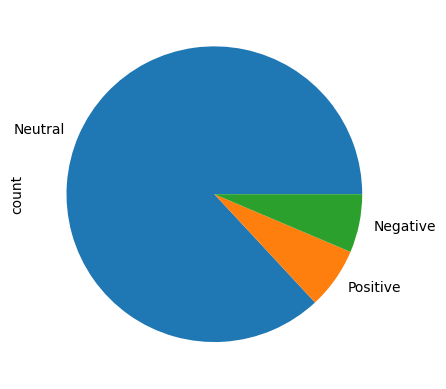

In [ ]:
financial_news.Sentiment.value_counts().plot.pie()
plt.show()

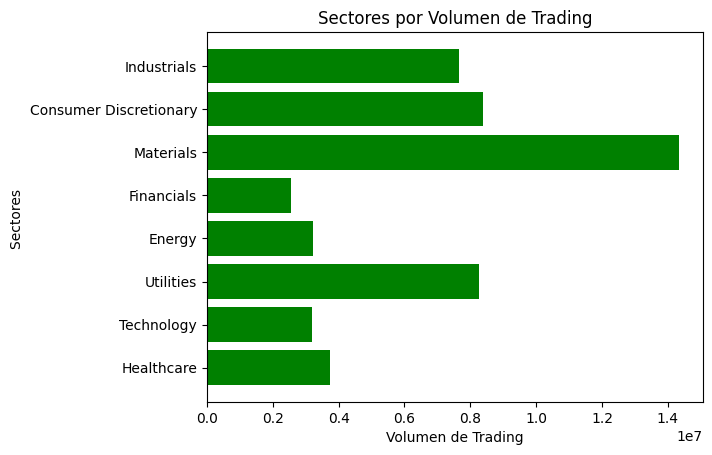

In [ ]:
plt.barh(financial_news['Sector'], financial_news['Trading_Volume'], color='green')
plt.title('Sectores por Volumen de Trading')
plt.xlabel('Volumen de Trading')
plt.ylabel('Sectores ')
plt.show()


<Axes: title={'center': 'Top 5 sectores con mayor volumen de trading'}, xlabel='Sector', ylabel='Trading Volume'>

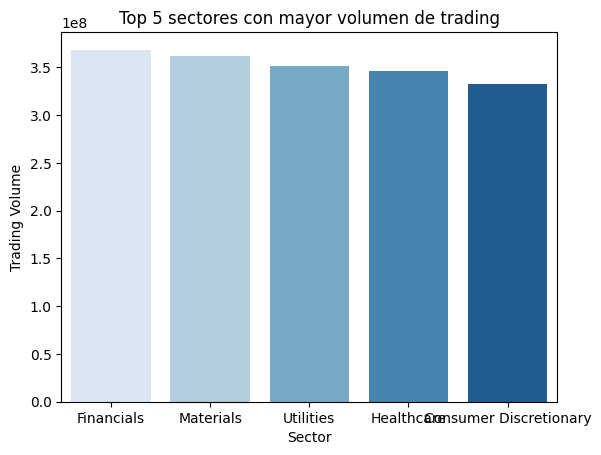

In [ ]:
top_sectors = financial_news.groupby('Sector')['Trading_Volume'].sum().sort_values(ascending = False).reset_index().head(5)
plt.title('Top 5 sectores con mayor volumen de trading')
plt.xlabel('Sector')
plt.ylabel('Trading Volume')
sns.barplot(data = top_sectors,x= 'Sector', y = 'Trading_Volume', hue = "Sector", palette = 'Blues')

In [ ]:
# Asegúrate de que Date esté en formato datetime
financial_news['Date'] = pd.to_datetime(financial_news['Date'])

# Crear columna de mes
financial_news['Month'] = financial_news['Date'].dt.to_period('M').dt.to_timestamp()

# Agrupar por mes y compañía, calculando la media (puedes usar mediana o suma si prefieres)
monthly_avg = financial_news.groupby(['Month', 'Related_Company'])['Index_Change_Percent'].mean().reset_index()

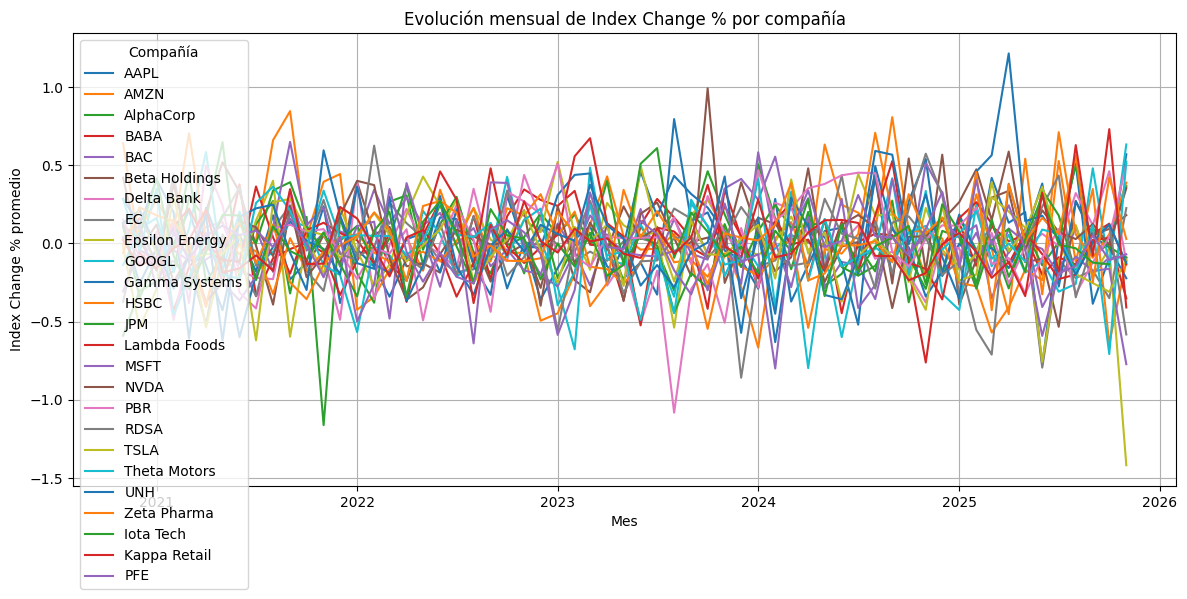

In [ ]:
plt.figure(figsize=(12, 6))

# Graficar cada compañía
for company in monthly_avg['Related_Company'].unique():
    subset = monthly_avg[monthly_avg['Related_Company'] == company]
    plt.plot(subset['Month'], subset['Index_Change_Percent'], label=company)

plt.title('Evolución mensual de Index Change % por compañía')
plt.xlabel('Mes')
plt.ylabel('Index Change % promedio')
plt.legend(title='Compañía')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Diccionario de mapeo
sentiment_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}

# Modificar la columna original
financial_news['Sentiment'] = financial_news['Sentiment'].map(sentiment_map)

In [ ]:
# Diccionario de mapeo
impact_map = {'Low': 0, 'Medium': 1, 'High': 2}

# Modificar la columna original
financial_news['Impact_Level'] = financial_news['Impact_Level'].map(impact_map)

In [ ]:
financial_news.Sector.unique()

array(['Healthcare', 'Technology', 'Utilities', 'Energy', 'Financials',
       'Materials', 'Consumer Discretionary', 'Industrials'], dtype=object)

In [ ]:
financial_news.Market_Event.unique()

array(['Macro Data', 'Earnings', 'Other', 'Product Launch', 'M&A',
       'Dividend', 'Regulation', 'Guidance'], dtype=object)

In [ ]:
financial_news.Market_Index.unique()

array(['FTSE 100', 'S&P 500', 'DAX', 'NASDAQ', 'COLCAP', 'Nikkei 225',
       'MSCI Emerging'], dtype=object)

In [ ]:
financial_news.Related_Company.unique()

array(['AlphaCorp', 'Delta Bank', 'GOOGL', 'HSBC', 'Gamma Systems',
       'Theta Motors', 'BAC', 'AMZN', 'Beta Holdings', 'Zeta Pharma',
       'RDSA', 'PBR', 'EC', 'MSFT', 'AAPL', 'BABA', 'Lambda Foods', 'UNH',
       'JPM', 'NVDA', 'TSLA', 'Epsilon Energy', 'Kappa Retail',
       'Iota Tech', 'PFE'], dtype=object)

In [ ]:
# devuelve códigos 0..n_unique-1 y los valores únicos
codes, uniques = pd.factorize(financial_news['Sector'], sort=True)
financial_news['Sector'] = codes
# opcional: guardar el mapeo en un diccionario
sector_map = {val: idx for idx, val in enumerate(uniques)}

In [ ]:
# devuelve códigos 0..n_unique-1 y los valores únicos
codes, uniques = pd.factorize(financial_news['Market_Event'], sort=True)
financial_news['Market_Event'] = codes
# opcional: guardar el mapeo en un diccionario
Market_Event_map = {val: idx for idx, val in enumerate(uniques)}


In [ ]:
# devuelve códigos 0..n_unique-1 y los valores únicos
codes, uniques = pd.factorize(financial_news['Market_Index'], sort=True)
financial_news['Market_Index'] = codes
# opcional: guardar el mapeo en un diccionario
Market_Index_map = {val: idx for idx, val in enumerate(uniques)}

In [ ]:
# devuelve códigos 0..n_unique-1 y los valores únicos
codes, uniques = pd.factorize(financial_news['Related_Company'], sort=True)
financial_news['Related_Company'] = codes
# opcional: guardar el mapeo en un diccionario
Related_Company_map = {val: idx for idx, val in enumerate(uniques)}

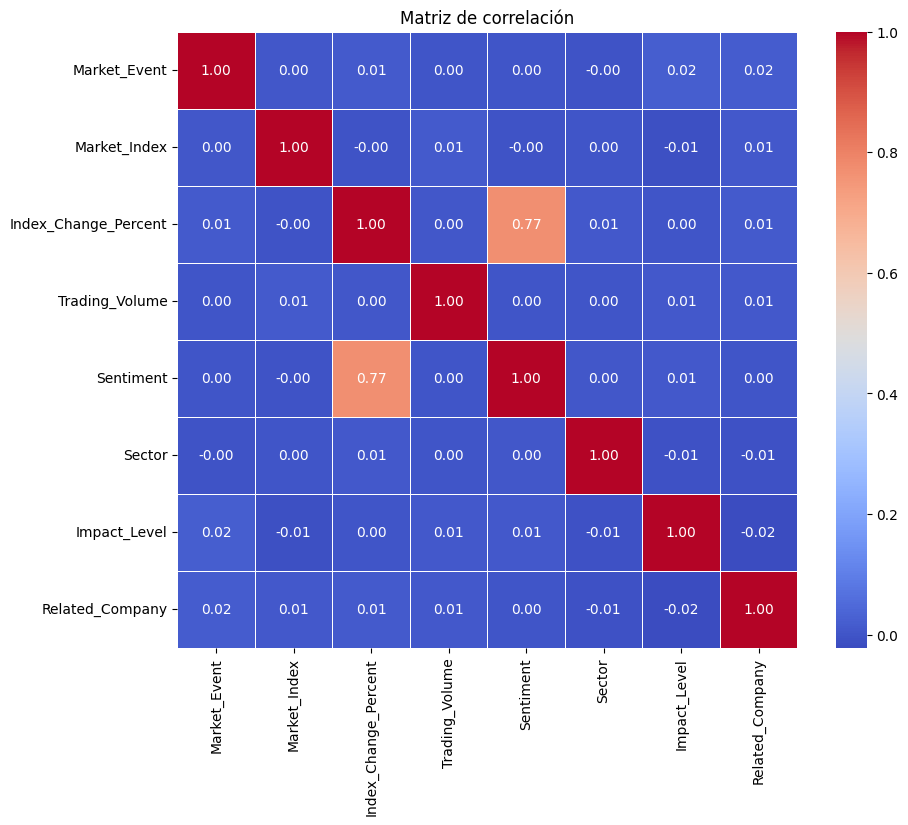

In [ ]:
correlation_matrix = financial_news.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación")
plt.show()

In [ ]:
modelos = [
    ("Regresión Lineal", LinearRegression()),
    ("Arbol de Decisión", DecisionTreeRegressor()),
    ("Bosque Aleatorio", RandomForestRegressor())
]

In [ ]:
financial_news

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url,Month
0,2020-11-14,AlphaCorp reports modest EPS beating estimates,Bloomberg,4,2,-0.999,841274,-1,3,1,2,https://news.example.com/1053,2020-11-01
1,2020-11-14,Regulator fines Delta Bank for soft demand,Reuters,1,6,-0.399,204087,0,6,1,6,https://news.example.com/5406,2020-11-01
2,2020-11-14,Regulator fines GOOGL for supply chain issues,Bloomberg,4,1,-0.409,234876,0,7,0,9,https://news.example.com/2815,2020-11-01
3,2020-11-14,GOOGL and Gamma Systems expand partnership in ...,CNBC,1,6,0.181,309372,0,1,0,9,https://news.example.com/3124,2020-11-01
4,2020-11-15,HSBC and Beta Holdings expand partnership in U...,MarketWatch,1,4,0.013,38231,0,3,0,11,https://news.example.com/1286,2020-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025-11-11,PBR reports strong revenue beating estimates,Reuters,4,3,0.141,217850,0,4,0,18,https://news.example.com/2391,2025-11-01
9996,2025-11-12,JPM misses earnings as supply chain issues wei...,Bloomberg,4,1,-0.124,339467,0,3,0,13,https://news.example.com/4115,2025-11-01
9997,2025-11-12,AAPL misses earnings as soft demand weighs on ...,Bloomberg,1,5,1.251,253969,1,2,2,0,https://news.example.com/4672,2025-11-01
9998,2025-11-13,Kappa Retail unveils new cloud service for eme...,Reuters,6,5,0.086,350066,0,0,1,14,https://news.example.com/2021,2025-11-01


In [ ]:
y = financial_news["Index_Change_Percent"]
y

,Index_Change_Percent
0,-0.999
1,-0.399
2,-0.409
3,0.181
4,0.013
...,...
9995,0.141
9996,-0.124
9997,1.251
9998,0.086


In [ ]:
X =  financial_news.drop(["Index_Change_Percent","Headline","Source","News_Url","Month","Date"],axis = 1)
X

,Market_Event,Market_Index,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company
0,4,2,841274,-1,3,1,2
1,1,6,204087,0,6,1,6
2,4,1,234876,0,7,0,9
3,1,6,309372,0,1,0,9
4,1,4,38231,0,3,0,11
...,...,...,...,...,...,...,...
9995,4,3,217850,0,4,0,18
9996,4,1,339467,0,3,0,13
9997,1,5,253969,1,2,2,0
9998,6,5,350066,0,0,1,14


In [ ]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(X, y, train_size=0.7, random_state=42)

In [ ]:
X_entrena

,Market_Event,Market_Index,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company
9069,1,4,278725,0,7,0,9
2603,2,6,91409,0,6,0,24
7738,2,5,1269100,0,6,1,15
1579,1,2,202107,1,2,1,9
5058,4,6,1235290,-1,4,0,2
...,...,...,...,...,...,...,...
5734,3,0,701292,0,2,1,15
5191,1,2,68142,0,6,0,4
5390,4,5,237352,0,0,0,12
860,1,2,102846,0,5,0,19


In [ ]:
for nombre, modelo in modelos:
  modelo.fit(X_entrena, y_entrena)
  puntaje = modelo.score(X_prueba, y_prueba)
  print(f'{nombre}: {puntaje:.10f}')

Regresión Lineal: 0.5806355930
Arbol de Decisión: 0.1592422026
Bosque Aleatorio: 0.5566513737


In [ ]:
modelo = RandomForestRegressor()
modelo.fit(X_entrena, y_entrena)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Score Train: 0.9402689988892635
Score Validación: 0.5546157967798937


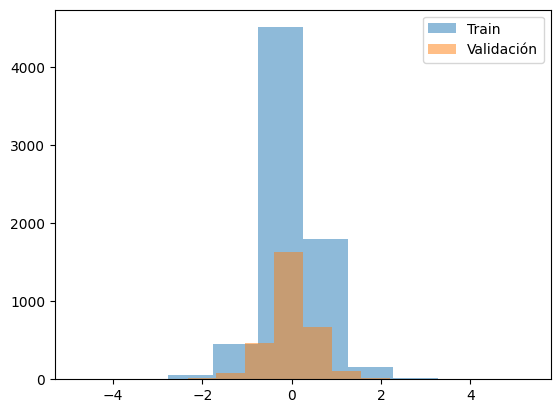

In [ ]:
# 1. Verifica el score en ambos conjuntos
print(f"Score Train: {modelo.score(X_entrena, y_entrena)}")
print(f"Score Validación: {modelo.score(X_prueba, y_prueba)}")

# 2. Revisa la distribución de tus datos
import matplotlib.pyplot as plt
plt.hist(y_entrena, alpha=0.5, label='Train')
plt.hist(y_prueba, alpha=0.5, label='Validación')
plt.legend()
plt.show()

In [ ]:
y_pred = modelo.predict(X_prueba)
y_pred

array([-0.01718, -0.21421,  0.18028, ...,  0.04416,  0.08228, -0.09125])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, explained_variance_score

# Supongamos que ya tienes:
# y_prueba: valores reales
# y_pred: predicciones del modelo

mae = mean_absolute_error(y_prueba, y_pred)
mse = mean_squared_error(y_prueba, y_pred)
mse = mean_squared_error(y_prueba, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_prueba, y_pred)
evs = explained_variance_score(y_prueba, y_pred)

# Mostrar resultados
print(f"MAE (Error absoluto medio): {mae:.4f}")
print(f"MSE (Error cuadrático medio): {mse:.4f}")
print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"Explained Variance Score: {evs:.4f}")

MAE (Error absoluto medio): 0.2980
MSE (Error cuadrático medio): 0.1428
RMSE (Raíz del error cuadrático medio): 0.3779
R² (Coeficiente de determinación): 0.5546
Explained Variance Score: 0.5551


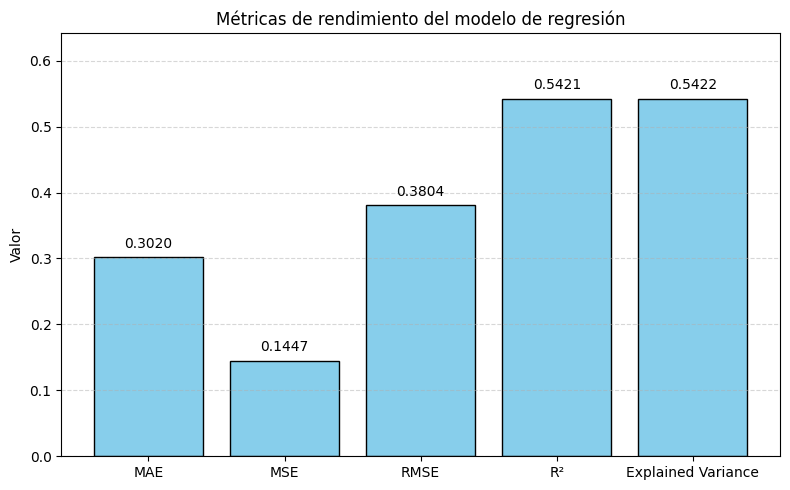

In [ ]:
# Métricas calculadas
metrics = {
    "MAE": 0.3020,
    "MSE": 0.1447,
    "RMSE": 0.3804,
    "R²": 0.5421,
    "Explained Variance": 0.5422
}

# Preparar datos
names = list(metrics.keys())
values = list(metrics.values())

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(names, values, color='skyblue', edgecolor='black')

# Añadir etiquetas de valor encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom')

# Personalizar gráfico
plt.title("Métricas de rendimiento del modelo de regresión")
plt.ylabel("Valor")
plt.ylim(0, max(values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()